In [1]:
# %% ===============================
# 1. INSTALL EXTRA LIBRARIES
# ===============================
!pip install nltk rouge-score --quiet

In [2]:
# %% ===============================
# 2. IMPORTS
# ===============================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from PIL import Image

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os, random, math
from collections import defaultdict
from pathlib import Path
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from rouge_score import rouge_scorer

In [3]:
# ===============================
# 3. DEVICE SETUP
# ===============================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
# %% ===============================
# 4. HYPERPARAMETERS
# ===============================
EMBED_DIM     = 256
HIDDEN_DIM    = 512
NUM_LAYERS    = 2        # was 1 → more capacity
DROPOUT       = 0.4      # was 0.3 → slightly more regularization for 2 layers
BATCH_SIZE    = 32
NUM_EPOCHS    = 50
LR            = 3e-3     
GRAD_CLIP     = 5.0      # was 1.0 → allow larger gradients with higher LR
MAX_SEQ_LEN   = 40
PATIENCE      = 10
LABEL_SMOOTH  = 0.1
WEIGHT_DECAY  = 1e-4

# Scheduled sampling: start with teacher forcing, linearly reduce
SS_START      = 1.0      # 100% teacher forcing at epoch 0
SS_END        = 0.7      # 70% teacher forcing at last epoch

In [5]:
# %% ===============================
# 5. LOAD ENCODER CHECKPOINT
# ===============================
ENCODER_PATH = '/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/encoder_for_lstm.pth'

ckpt = torch.load(ENCODER_PATH, map_location=device)

word2idx    = ckpt['word2idx']
idx2word    = ckpt['idx2word']
vocab_size  = ckpt['vocab_size']
pad_idx     = ckpt['pad_idx']
start_idx   = ckpt['start_idx']
end_idx     = ckpt['end_idx']
img_mean    = ckpt['img_mean']
img_std     = ckpt['img_std']

print(f"Vocab size:     {vocab_size}")
print(f"Embed dim:      {ckpt['embed_dim']}")
print(f"PAD={pad_idx}, START={start_idx}, END={end_idx}")

Vocab size:     4207
Embed dim:      256
PAD=0, START=1, END=2


In [6]:
# %% ===============================
# 6. DATA PATHS + EXPLORE
# ===============================
TRAIN_CSV = '/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/for data kaggle/for data kaggle/Stage2_clean_data_final/train_caption.csv'
VAL_CSV   = '/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/for data kaggle/for data kaggle/Stage2_clean_data_final/val_caption.csv'
TEST_CSV  = '/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/for data kaggle/for data kaggle/Stage2_clean_data_final/test_caption.csv'
IMG_DIR   = '/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/images/images'

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Columns: {train_df.columns.tolist()}")
print(train_df.head(2))

Train: 10984, Val: 1373, Test: 1374
Columns: ['local_path', 'description', 'room_type', 'wc']
                                 local_path  \
0  images/home-office/home-office_00740.jpg   
1            images/pool/poolroom_02998.jpg   

                                         description    room_type  wc  
0  freestanding desk carpeted and beige floor stu...  home-office  11  
1  Hot tub - backyard tile and l-shaped hot tub idea         pool  10  


In [7]:
# %% ===============================
# 7. DATASET + DATALOADERS
# ===============================
# Stage2 caption CSVs have columns: local_path, description, room_type, wc — no
# precomputed 'tokens'. We tokenize the raw `description` here using word2idx
# from the encoder checkpoint. (If you later switch to Stage3 split_*.csv, the
# 'tokens' column there is pre-tokenized; you can branch on column presence.)

# Pick UNK index from the checkpoint, or fall back to a sensible default
unk_idx = ckpt.get('unk_idx', None)
if unk_idx is None:
    for k in ('<UNK>', '<unk>', 'UNK', '<unknown>'):
        if k in word2idx:
            unk_idx = word2idx[k]
            break
    if unk_idx is None:
        unk_idx = 3   # preprocessing convention: PAD=0 START=1 END=2 UNK=3


def tokenize_caption(text, max_len=MAX_SEQ_LEN):
    """Lowercase + whitespace split + word2idx lookup, with START/END/PAD."""
    words = str(text).lower().split()
    # leave room for START + END
    words = words[:max_len - 2]
    ids = [start_idx] + [word2idx.get(w, unk_idx) for w in words] + [end_idx]
    # pad to fixed length
    ids = ids + [pad_idx] * (max_len - len(ids))
    return ids


class CaptionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, max_seq_len=MAX_SEQ_LEN):
        self.df          = df.reset_index(drop=True)
        self.img_dir     = Path(img_dir)
        self.transform   = transform
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # local_path like "images/kitchen/kitchen_00001.jpg" — strip leading 'images/'
        rel_path = row['local_path'].split('/', 1)[-1]
        image    = Image.open(self.img_dir / rel_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Tokenize on the fly (or reuse precomputed 'tokens' if present)
        if 'tokens' in row.index and not isinstance(row['tokens'], float):
            toks = row['tokens']
            if isinstance(toks, str):
                toks = eval(toks)
        else:
            toks = tokenize_caption(row['description'], self.max_seq_len)

        return image, torch.tensor(toks[:self.max_seq_len], dtype=torch.long)


train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=img_mean, std=img_std),
])
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=img_mean, std=img_std),
])


train_dataset = CaptionDataset(train_df, IMG_DIR, train_transform)
val_dataset   = CaptionDataset(val_df,   IMG_DIR, val_test_transform)
test_dataset  = CaptionDataset(test_df,  IMG_DIR, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

# Smoke test — confirm the dataset returns properly-shaped tensors
imgs, toks = next(iter(train_loader))
print(f'Image shape: {imgs.shape}, Token shape: {toks.shape}')
print(f'Sample tokens[0][:10] = {toks[0][:10].tolist()}')


Train batches: 344
Val   batches: 43
Test  batches: 43
Image shape: torch.Size([32, 3, 224, 224]), Token shape: torch.Size([32, 40])
Sample tokens[0][:10] = [1, 530, 527, 2250, 3, 1656, 799, 1440, 137, 1629]


In [8]:
# %% ===============================
# 8. ENCODER (exact copy — unchanged)
# ===============================
class EncoderResNet50(nn.Module):
    def __init__(self, embed_dim=256, fine_tune=False, dropout=0.0):
        super().__init__()
        backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        for p in backbone.parameters():
            p.requires_grad = False
        if fine_tune:
            for p in backbone.layer4.parameters():
                p.requires_grad = True
        in_features = backbone.fc.in_features  # 2048
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.projection = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(1024, embed_dim),
            nn.LayerNorm(embed_dim),
        )

    def forward(self, images):
        features = self.backbone(images)
        return self.projection(features)


encoder = EncoderResNet50(embed_dim=EMBED_DIM, fine_tune=False, dropout=0.0).to(device)
encoder.load_state_dict(ckpt['encoder_state_dict'])
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

print("Encoder loaded and frozen ✓")
with torch.no_grad():
    dummy = torch.zeros(2, 3, 224, 224).to(device)
    print(f"Encoder output shape: {encoder(dummy).shape}")  # [2, 256]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


Encoder loaded and frozen ✓
Encoder output shape: torch.Size([2, 256])


In [9]:
# %% ===============================
# 9. IMPROVED LSTM DECODER (v2)
# ===============================
class LSTMDecoderV2(nn.Module):

    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512,
                 num_layers=2, dropout=0.4, pad_idx=0):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim  = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Word embedding
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Feature gate: at each timestep, modulate which image features matter
        # Input: current hidden state → gate vector → element-wise multiply with features
        self.feat_gate = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, embed_dim),
            nn.Sigmoid()
        )

        # LSTM: input = [word_embed + gated_image_features] = embed_dim*2
        self.lstm = nn.LSTM(
            input_size=embed_dim * 2,   # word embed + gated features
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Initialize h0, c0 from image features
        self.init_h = nn.Linear(embed_dim, hidden_dim * num_layers)
        self.init_c = nn.Linear(embed_dim, hidden_dim * num_layers)

        # Output projection
        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(hidden_dim, vocab_size)

        # Weight tying: share embedding and output weights
        # This significantly reduces parameters and improves generalization
        if embed_dim == hidden_dim:
            self.fc_out.weight = self.embed.weight
        else:
            # Need a projection if dims differ
            self.out_proj = nn.Linear(hidden_dim, embed_dim, bias=False)
            self.fc_out   = nn.Linear(embed_dim, vocab_size, bias=True)
            self.fc_out.weight = self.embed.weight

        self._init_weights()

    def _init_weights(self):
        """Proper initialization for LSTM and linear layers."""
        # Embedding: small normal
        nn.init.normal_(self.embed.weight, mean=0, std=0.01)
        # Zero out padding embedding
        with torch.no_grad():
            self.embed.weight[pad_idx].fill_(0)

        # LSTM: orthogonal for recurrent weights, xavier for input weights
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                # Set forget gate bias to 1.0 (helps LSTM remember longer)
                n = param.size(0)
                param.data[n // 4 : n // 2].fill_(1.0)

        # Linear layers: xavier
        for module in [self.init_h, self.init_c, self.feat_gate[0]]:
            if hasattr(module, 'weight'):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _init_hidden(self, features):
        """Initialize LSTM hidden states from image features."""
        B = features.size(0)
        h0 = self.init_h(features)  # [B, hidden*layers]
        c0 = self.init_c(features)  # [B, hidden*layers]
        h0 = h0.view(B, self.num_layers, self.hidden_dim).permute(1, 0, 2).contiguous()
        c0 = c0.view(B, self.num_layers, self.hidden_dim).permute(1, 0, 2).contiguous()
        return h0, c0

    def forward(self, features, captions, ss_prob=0.0):
 
        B, T = captions.size()
        T_out = T - 1  # exclude last token from input

        h, c = self._init_hidden(features)
        embeddings = self.embed(captions)  # [B, T, embed_dim]

        outputs = []
        for t in range(T_out):
            # Decide input: teacher forcing or model's own prediction
            if t == 0 or ss_prob == 0.0 or random.random() >= ss_prob:
                word_embed = embeddings[:, t, :]  # [B, embed_dim]
            else:
                # Use model's own previous prediction
                prev_logits = outputs[-1]         # [B, vocab_size]
                prev_token  = prev_logits.argmax(dim=-1)  # [B]
                word_embed  = self.embed(prev_token)      # [B, embed_dim]

            # Feature gate: modulate image features based on current context
            h_top = h[-1]  # top layer hidden state [B, hidden_dim]
            gate_input = torch.cat([h_top, word_embed], dim=1)  
            gate = self.feat_gate(gate_input)                    
            gated_features = gate * features                     

            # LSTM input: word embedding + gated image features
            lstm_input = torch.cat([word_embed, gated_features], dim=1)  # [B, embed_dim*2]
            lstm_input = lstm_input.unsqueeze(1)  # [B, 1, embed_dim*2]

            out, (h, c) = self.lstm(lstm_input, (h, c))  # out: [B, 1, hidden_dim]
            out = out.squeeze(1)  # [B, hidden_dim]

            out = self.dropout(out)

            # Project to vocab
            if hasattr(self, 'out_proj'):
                out = self.out_proj(out)  # [B, embed_dim]
            logits = self.fc_out(out)     # [B, vocab_size]

            outputs.append(logits)

        outputs = torch.stack(outputs, dim=1)  # [B, T-1, vocab_size]
        return outputs


# Build decoder
decoder = LSTMDecoderV2(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_idx=pad_idx
).to(device)

total_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"Decoder trainable params: {total_params:,}")

# Smoke test
with torch.no_grad():
    df = torch.zeros(2, 256).to(device)
    dc = torch.zeros(2, 40, dtype=torch.long).to(device)
    do = decoder(df, dc)
    print(f"Decoder output shape: {do.shape}")  # [2, 39, vocab_size]

Decoder trainable params: 6,137,967
Decoder output shape: torch.Size([2, 39, 4207])


In [10]:
# %% ===============================
# 10. LOSS, OPTIMIZER, SCHEDULER
# ===============================
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=LABEL_SMOOTH)

optimizer = optim.AdamW(decoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# OneCycleLR: warm-up → peak → cosine decay (much better than ReduceLROnPlateau for from-scratch)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    total_steps=total_steps,
    pct_start=0.1,       # 10% warm-up
    anneal_strategy='cos',
    div_factor=25,       # start_lr = max_lr / 25
    final_div_factor=1e4 # end_lr = max_lr / 10000
)

print("Loss, Optimizer, OneCycleLR Scheduler ready ✓")
print(f"  Peak LR:    {LR}")
print(f"  Start LR:   {LR / 25:.6f}")
print(f"  Total steps: {total_steps}")

Loss, Optimizer, OneCycleLR Scheduler ready ✓
  Peak LR:    0.003
  Start LR:   0.000120
  Total steps: 17200


In [11]:
# %% ===============================
# 11. TRAINING LOOP (with scheduled sampling)
# ===============================
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'lr':         []
}

best_val_loss    = float('inf')
patience_counter = 0

print(f"\n{'='*60}")
print(f"Training started — {NUM_EPOCHS} epochs, patience={PATIENCE}")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):

    # Scheduled sampling probability (linearly increase from 0 to 0.3)
    ss_prob = (1.0 - SS_START) + (SS_START - SS_END) * (epoch / max(NUM_EPOCHS - 1, 1))
    ss_prob = max(0.0, min(ss_prob, 1.0 - SS_END))  # clamp

    # ── TRAIN ──────────────────────────────────────────────────────
    decoder.train()
    train_loss    = 0.0
    train_correct = 0
    train_tokens  = 0

    for images, captions in train_loader:
        images   = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        with torch.no_grad():
            features = encoder(images)               # [B, 256]

        logits  = decoder(features, captions, ss_prob=ss_prob)  # [B, T-1, V]
        targets = captions[:, 1:]                     # [B, T-1]

        loss = criterion(
            logits.reshape(-1, vocab_size),
            targets.reshape(-1)
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        scheduler.step()   # step per batch for OneCycleLR

        train_loss += loss.item()
        preds = logits.argmax(dim=-1)
        mask  = targets != pad_idx
        train_correct += ((preds == targets) & mask).sum().item()
        train_tokens  += mask.sum().item()

    avg_train_loss = train_loss    / len(train_loader)
    avg_train_acc  = train_correct / max(train_tokens, 1)

    # ── VALIDATION ─────────────────────────────────────────────────
    decoder.eval()
    val_loss    = 0.0
    val_correct = 0
    val_tokens  = 0

    with torch.no_grad():
        for images, captions in val_loader:
            images   = images.to(device, non_blocking=True)
            captions = captions.to(device, non_blocking=True)

            features = encoder(images)
            logits   = decoder(features, captions, ss_prob=0.0)  # no SS in val
            targets  = captions[:, 1:]

            loss = criterion(
                logits.reshape(-1, vocab_size),
                targets.reshape(-1)
            )

            val_loss += loss.item()
            preds = logits.argmax(dim=-1)
            mask  = targets != pad_idx
            val_correct += ((preds == targets) & mask).sum().item()
            val_tokens  += mask.sum().item()

    avg_val_loss = val_loss    / len(val_loader)
    avg_val_acc  = val_correct / max(val_tokens, 1)

    current_lr = optimizer.param_groups[0]['lr']

    # ── SAVE BEST ──────────────────────────────────────────────────
    flag = ''
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        torch.save({
            'epoch':         epoch + 1,
            'decoder':       decoder.state_dict(),
            'optimizer':     optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'vocab_size':    vocab_size,
            'embed_dim':     EMBED_DIM,
            'hidden_dim':    HIDDEN_DIM,
            'num_layers':    NUM_LAYERS,
        }, '/kaggle/working/best_lstm_decoder_v2.pth')
        flag = '  saved'
    else:
        patience_counter += 1

    # ── LOG ────────────────────────────────────────────────────────
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(avg_val_acc)
    history['lr'].append(current_lr)

    print(f"Epoch [{epoch+1:>2}/{NUM_EPOCHS}]  "
          f"lr={current_lr:.6f}  ss={ss_prob:.2f}  "
          f"train={avg_train_loss:.4f}/{avg_train_acc:.4f}  "
          f"val={avg_val_loss:.4f}/{avg_val_acc:.4f}{flag}")

    # ── EARLY STOPPING ─────────────────────────────────────────────
    if patience_counter >= PATIENCE:
        print(f"\n Early stopping — no improvement for {PATIENCE} epochs")
        break

print(f"\n Best val loss: {best_val_loss:.4f}")


Training started — 50 epochs, patience=10

Epoch [ 1/50]  lr=0.000395  ss=0.00  train=5.7001/0.1671  val=5.2395/0.1762  saved
Epoch [ 2/50]  lr=0.001116  ss=0.01  train=4.9169/0.1890  val=4.6178/0.2469  saved
Epoch [ 3/50]  lr=0.002006  ss=0.01  train=4.0049/0.3961  val=3.7116/0.4587  saved
Epoch [ 4/50]  lr=0.002726  ss=0.02  train=3.6480/0.4737  val=3.5443/0.4853  saved
Epoch [ 5/50]  lr=0.003000  ss=0.02  train=3.5448/0.4890  val=3.4671/0.4956  saved
Epoch [ 6/50]  lr=0.002996  ss=0.03  train=3.4674/0.5000  val=3.4101/0.5039  saved
Epoch [ 7/50]  lr=0.002985  ss=0.04  train=3.4097/0.5073  val=3.3933/0.5076  saved
Epoch [ 8/50]  lr=0.002967  ss=0.04  train=3.3637/0.5128  val=3.3617/0.5127  saved
Epoch [ 9/50]  lr=0.002942  ss=0.05  train=3.3337/0.5167  val=3.3507/0.5151  saved
Epoch [10/50]  lr=0.002909  ss=0.06  train=3.2946/0.5224  val=3.3418/0.5153  saved
Epoch [11/50]  lr=0.002870  ss=0.06  train=3.2679/0.5239  val=3.3349/0.5154  saved
Epoch [12/50]  lr=0.002824  ss=0.07  train=

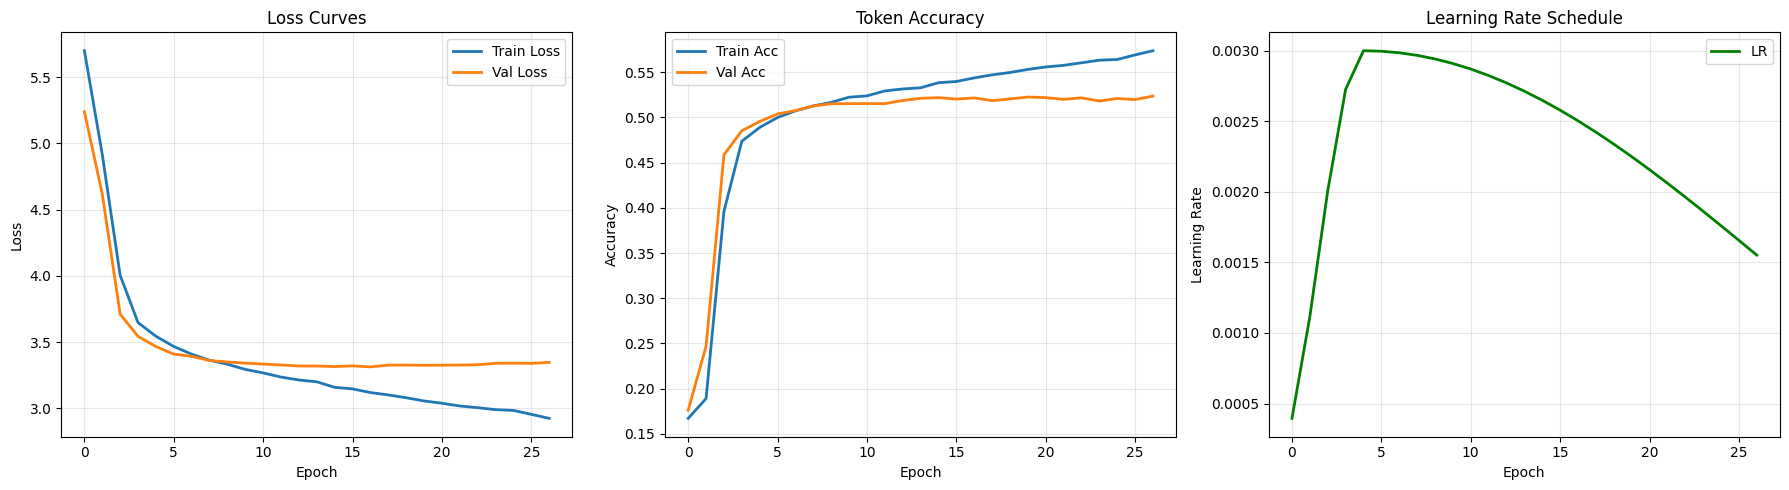

Training curves saved 


In [12]:
# %% ===============================
# 12. PLOT TRAINING CURVES
# ===============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val Acc',   linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Token Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'], label='LR', linewidth=2, color='green')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Save history
with open('/kaggle/working/training_history_v2.json', 'w') as f:
    json.dump(history, f, indent=2)
print("Training curves saved ")


In [13]:
# %% ===============================
# 13. LOAD BEST MODEL
# ===============================
best_ckpt = torch.load('/kaggle/working/best_lstm_decoder_v2.pth', map_location=device)
decoder.load_state_dict(best_ckpt['decoder'])
decoder.eval()
print(f"Loaded best decoder from epoch {best_ckpt['epoch']}, val_loss={best_ckpt['best_val_loss']:.4f}")

Loaded best decoder from epoch 17, val_loss=3.3133


In [14]:
# %% ===============================
# 14. CAPTION GENERATION FUNCTIONS
# ===============================

# Download METEOR dependencies
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.translate.meteor_score import meteor_score as nltk_meteor
from nltk.tokenize import word_tokenize

def greedy_decode(encoder, decoder, image, max_len=MAX_SEQ_LEN):
    """Generate a caption using greedy decoding (pick best token each step)."""
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        features = encoder(image.unsqueeze(0).to(device))  # [1, 256]
        h, c = decoder._init_hidden(features)

        token = torch.tensor([[start_idx]], device=device)  # [1, 1]
        caption = []

        for t in range(max_len):
            word_embed = decoder.embed(token).squeeze(1)    # [1, embed_dim]

            h_top = h[-1]
            gate_input = torch.cat([h_top, word_embed], dim=1)
            gate = decoder.feat_gate(gate_input)
            gated_features = gate * features

            lstm_input = torch.cat([word_embed, gated_features], dim=1).unsqueeze(1)
            out, (h, c) = decoder.lstm(lstm_input, (h, c))
            out = out.squeeze(1)

            if hasattr(decoder, 'out_proj'):
                out = decoder.out_proj(out)
            logits = decoder.fc_out(out)

            next_token = logits.argmax(dim=-1)  # [1]
            token_id = next_token.item()

            if token_id == end_idx:
                break
            caption.append(token_id)
            token = next_token.unsqueeze(0)     # [1, 1]

    return ' '.join([idx2word.get(str(t), idx2word.get(t, '<UNK>')) for t in caption])


def beam_search_decode(encoder, decoder, image, beam_size=5, max_len=MAX_SEQ_LEN):
    """Generate caption using beam search for better quality."""
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        features = encoder(image.unsqueeze(0).to(device))  # [1, 256]
        h, c = decoder._init_hidden(features)

        # Each beam: (log_prob, token_list, h, c)
        beams = [(0.0, [start_idx], h, c)]
        completed = []

        for _ in range(max_len):
            candidates = []
            for log_prob, seq, h_b, c_b in beams:
                last_token = torch.tensor([[seq[-1]]], device=device)
                word_embed = decoder.embed(last_token).squeeze(1)

                h_top = h_b[-1]
                gate_input = torch.cat([h_top, word_embed], dim=1)
                gate = decoder.feat_gate(gate_input)
                gated_features = gate * features

                lstm_input = torch.cat([word_embed, gated_features], dim=1).unsqueeze(1)
                out, (h_new, c_new) = decoder.lstm(lstm_input, (h_b, c_b))
                out = out.squeeze(1)

                if hasattr(decoder, 'out_proj'):
                    out = decoder.out_proj(out)
                logits = decoder.fc_out(out)

                log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)
                top_probs, top_ids = log_probs.topk(beam_size)

                for i in range(beam_size):
                    tok = top_ids[i].item()
                    new_prob = log_prob + top_probs[i].item()
                    new_seq  = seq + [tok]

                    if tok == end_idx:
                        # Length normalize
                        score = new_prob / (len(new_seq) ** 0.7)
                        completed.append((score, new_seq))
                    else:
                        candidates.append((new_prob, new_seq, h_new, c_new))

            if not candidates:
                break

            # Keep top beam_size candidates
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_size]

            if len(completed) >= beam_size:
                break

        # Pick best completed beam, or best ongoing beam
        if completed:
            completed.sort(key=lambda x: x[0], reverse=True)
            best_seq = completed[0][1]
        else:
            best_seq = beams[0][1]

        # Remove START and END tokens
        caption_ids = [t for t in best_seq if t not in (start_idx, end_idx, pad_idx)]
        return ' '.join([idx2word.get(str(t), idx2word.get(t, '<UNK>')) for t in caption_ids])


In [15]:
# %% ===============================
# 15. CIDEr SCORE IMPLEMENTATION
# ===============================
from collections import Counter

def compute_cider(references, hypotheses, n=4):
    
    def get_ngrams(words, n):
        ngrams = Counter()
        for i in range(1, n + 1):
            for j in range(len(words) - i + 1):
                ngram = tuple(words[j:j+i])
                ngrams[ngram] += 1
        return ngrams

    def compute_tf(ngrams, length):
        tf = {}
        for ngram, count in ngrams.items():
            tf[ngram] = count / max(length, 1)
        return tf

    # Step 1: Compute document frequency (DF) from references
    num_docs = len(references)
    df = Counter()
    for refs in references:
        seen = set()
        for ref in refs:
            for ngram in get_ngrams(ref, n):
                if ngram not in seen:
                    df[ngram] += 1
                    seen.add(ngram)

    # Step 2: Compute TF-IDF for each hypothesis and reference, then cosine similarity
    scores = []
    for i in range(len(hypotheses)):
        hyp = hypotheses[i]
        refs = references[i]

        hyp_ngrams = get_ngrams(hyp, n)
        hyp_tf = compute_tf(hyp_ngrams, len(hyp))

        # TF-IDF for hypothesis
        hyp_tfidf = {}
        for ngram, tf_val in hyp_tf.items():
            idf = np.log(max(1.0, num_docs) / max(1.0, df.get(ngram, 0)))
            hyp_tfidf[ngram] = tf_val * idf

        ref_scores = []
        for ref in refs:
            ref_ngrams = get_ngrams(ref, n)
            ref_tf = compute_tf(ref_ngrams, len(ref))

            ref_tfidf = {}
            for ngram, tf_val in ref_tf.items():
                idf = np.log(max(1.0, num_docs) / max(1.0, df.get(ngram, 0)))
                ref_tfidf[ngram] = tf_val * idf

            # Cosine similarity
            all_ngrams = set(hyp_tfidf.keys()) | set(ref_tfidf.keys())
            dot = sum(hyp_tfidf.get(ng, 0) * ref_tfidf.get(ng, 0) for ng in all_ngrams)
            norm_h = np.sqrt(sum(v**2 for v in hyp_tfidf.values())) + 1e-8
            norm_r = np.sqrt(sum(v**2 for v in ref_tfidf.values())) + 1e-8
            ref_scores.append(dot / (norm_h * norm_r))

        scores.append(np.mean(ref_scores) if ref_scores else 0.0)

    return 10.0 * np.mean(scores)  # CIDEr is typically scaled by 10


Sample Captions (Greedy vs Beam Search)


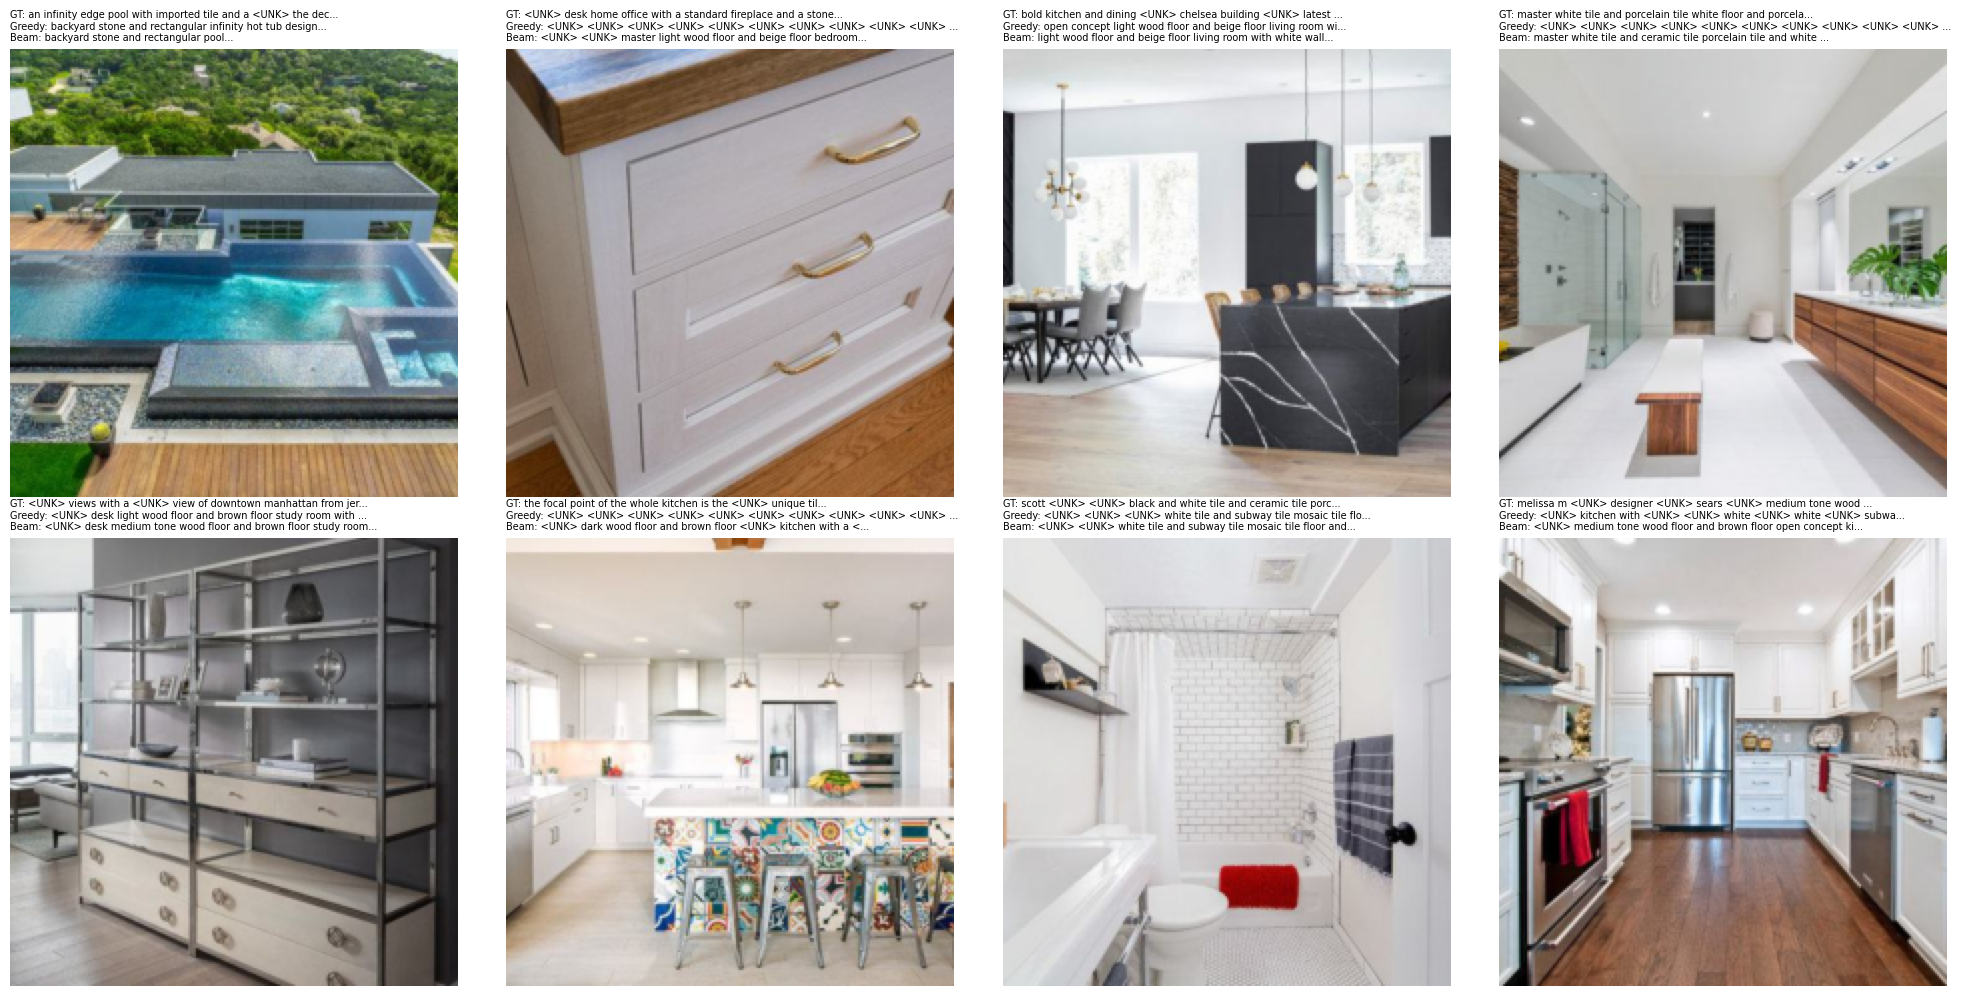

In [17]:
# %% ===============================
# 16. QUALITATIVE EXAMPLES
# ===============================
print("="*60)
print("Sample Captions (Greedy vs Beam Search)")
print("="*60)

test_dataset_vis = CaptionDataset(test_df, IMG_DIR, val_test_transform)  # ← FIXED: test_df not TEST_CSV

# Denormalize for display
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(img_mean, img_std)],
    std=[1/s for s in img_std]
)

num_samples = 8
indices = random.sample(range(len(test_dataset_vis)), num_samples)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    image, tokens = test_dataset_vis[idx]

    # Get ground truth caption
    gt_ids = [t.item() for t in tokens if t.item() not in (start_idx, end_idx, pad_idx)]
    gt_caption = ' '.join([idx2word.get(str(t), idx2word.get(t, '<UNK>')) for t in gt_ids])

    # Generate captions
    greedy_cap = greedy_decode(encoder, decoder, image)
    beam_cap   = beam_search_decode(encoder, decoder, image, beam_size=5)

    # Display
    img_display = inv_normalize(image).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img_display)
    axes[i].set_title(f"GT: {gt_caption[:60]}...\n"
                      f"Greedy: {greedy_cap[:60]}...\n"
                      f"Beam: {beam_cap[:60]}...",
                      fontsize=7, ha='left', loc='left')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_captions_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# %% ===============================
# 17. FULL EVALUATION (BLEU, METEOR, ROUGE-L, CIDEr)
# ===============================
print("\n" + "="*60)
print("Full Evaluation on Test Set")
print("="*60)

references_all = []
hypotheses_greedy = []
hypotheses_beam   = []
room_types_all    = []

test_df_eval = pd.read_csv(TEST_CSV)
decoder.eval()

for idx in range(len(test_dataset_vis)):
    image, tokens = test_dataset_vis[idx]

    # Ground truth
    gt_ids = [t.item() for t in tokens if t.item() not in (start_idx, end_idx, pad_idx)]
    gt_words = [idx2word.get(str(t), idx2word.get(t, '<UNK>')) for t in gt_ids]
    references_all.append([gt_words])  # corpus_bleu expects list of references

    # Room type
    room_types_all.append(test_df_eval.iloc[idx]['room_type'])

    # Greedy
    greedy_cap = greedy_decode(encoder, decoder, image)
    hypotheses_greedy.append(greedy_cap.split())

    # Beam search (for a subset to save time)
    if idx < 500:
        beam_cap = beam_search_decode(encoder, decoder, image, beam_size=5)
        hypotheses_beam.append(beam_cap.split())

    if (idx + 1) % 200 == 0:
        print(f"  Evaluated {idx+1}/{len(test_dataset_vis)} images...")

print(f"  Evaluated {len(test_dataset_vis)}/{len(test_dataset_vis)} images... Done!")

# ── BLEU Scores ──
smooth = SmoothingFunction().method1
bleu1_greedy = corpus_bleu(references_all, hypotheses_greedy,
                           weights=(1.0, 0, 0, 0), smoothing_function=smooth)
bleu4_greedy = corpus_bleu(references_all, hypotheses_greedy,
                           weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

bleu1_beam = corpus_bleu(references_all[:500], hypotheses_beam,
                         weights=(1.0, 0, 0, 0), smoothing_function=smooth)
bleu4_beam = corpus_bleu(references_all[:500], hypotheses_beam,
                         weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

# ── METEOR Score ──
print("\nComputing METEOR...")
meteor_scores = []
for ref, hyp in zip(references_all, hypotheses_greedy):
    ref_str = ' '.join(ref[0])
    hyp_str = ' '.join(hyp)
    try:
        ref_tokens = word_tokenize(ref_str)
        hyp_tokens = word_tokenize(hyp_str)
        m = nltk_meteor([ref_tokens], hyp_tokens)
    except Exception:
        m = nltk_meteor([ref_str.split()], hyp_str.split())
    meteor_scores.append(m)
avg_meteor = np.mean(meteor_scores)

# ── ROUGE-L Score ──
print("Computing ROUGE-L...")
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_scores = []
for ref, hyp in zip(references_all, hypotheses_greedy):
    ref_str = ' '.join(ref[0])
    hyp_str = ' '.join(hyp)
    score = scorer.score(ref_str, hyp_str)
    rouge_scores.append(score['rougeL'].fmeasure)
avg_rougeL = np.mean(rouge_scores)

# ── CIDEr Score ──
print("Computing CIDEr...")
cider_score = compute_cider(references_all, hypotheses_greedy)

# ── Room Synonym Dictionary (for smarter matching) ──
ROOM_SYNONYMS = {
    'bathroom':    ['bathroom', 'bath', 'shower', 'tub', 'vanity', 'toilet', 'sink', 'faucet', 'tile'],
    'bedroom':     ['bedroom', 'bed', 'mattress', 'pillow', 'nightstand', 'headboard', 'sleeping', 'duvet'],
    'home-office': ['office', 'desk', 'study', 'workspace', 'workstation', 'computer', 'bookshelf', 'shelving', 'chair'],
    'kitchen':     ['kitchen', 'cabinet', 'counter', 'stove', 'oven', 'refrigerator', 'cooking', 'sink', 'island', 'appliance', 'backsplash'],
    'living-room': ['living', 'lounge', 'sofa', 'couch', 'fireplace', 'mantel', 'seating', 'coffee table', 'sectional'],
    'pool':        ['pool', 'swim', 'patio', 'outdoor', 'deck', 'backyard', 'spa', 'hot tub', 'water', 'lounge'],
}

def check_room_match(room_type, generated_text):
    """Check if generated caption matches the room type using synonyms."""
    room_key = room_type.lower()
    gen = generated_text.lower()
    synonyms = ROOM_SYNONYMS.get(room_key, room_key.replace('-', ' ').split())
    return any(syn in gen for syn in synonyms)

# ── Overall Room Accuracy ──
room_correct = 0
for idx in range(len(test_df_eval)):
    room = test_df_eval.iloc[idx]['room_type']
    gen  = ' '.join(hypotheses_greedy[idx])
    if check_room_match(room, gen):
        room_correct += 1
room_acc = room_correct / len(test_df_eval) * 100

# ── Print Results Table ──
print(f"\n{'='*40}")
print(f"{'Metric':<20} {'Greedy':<12} {'Beam-5':<12}")
print(f"{'='*40}")
print(f"{'BLEU-1':<20} {bleu1_greedy:<12.4f} {bleu1_beam:<12.4f}")
print(f"{'BLEU-4':<20} {bleu4_greedy:<12.4f} {bleu4_beam:<12.4f}")
print(f"{'METEOR':<20} {avg_meteor:<12.4f} {'—':<12}")
print(f"{'ROUGE-L':<20} {avg_rougeL:<12.4f} {'—':<12}")
print(f"{'CIDEr':<20} {cider_score:<12.4f} {'—':<12}")
print(f"{'Room Acc %':<20} {room_acc:<12.1f} {'—':<12}")
print(f"{'='*40}")



Full Evaluation on Test Set
  Evaluated 200/1374 images...
  Evaluated 400/1374 images...
  Evaluated 600/1374 images...
  Evaluated 800/1374 images...
  Evaluated 1000/1374 images...
  Evaluated 1200/1374 images...
  Evaluated 1374/1374 images... Done!

Computing METEOR...
Computing ROUGE-L...
Computing CIDEr...

Metric               Greedy       Beam-5      
BLEU-1               0.3201       0.1969      
BLEU-4               0.1337       0.0874      
METEOR               0.4170       —           
ROUGE-L              0.3288       —           
CIDEr                0.9058       —           
Room Acc %           63.9         —           



  ROOM-TYPE ACCURACY
  bathroom         79.4%  ███████████████
  bedroom          49.1%  █████████
  home-office      58.6%  ███████████
  kitchen          63.1%  ████████████
  living-room      57.6%  ███████████
  pool             76.8%  ███████████████


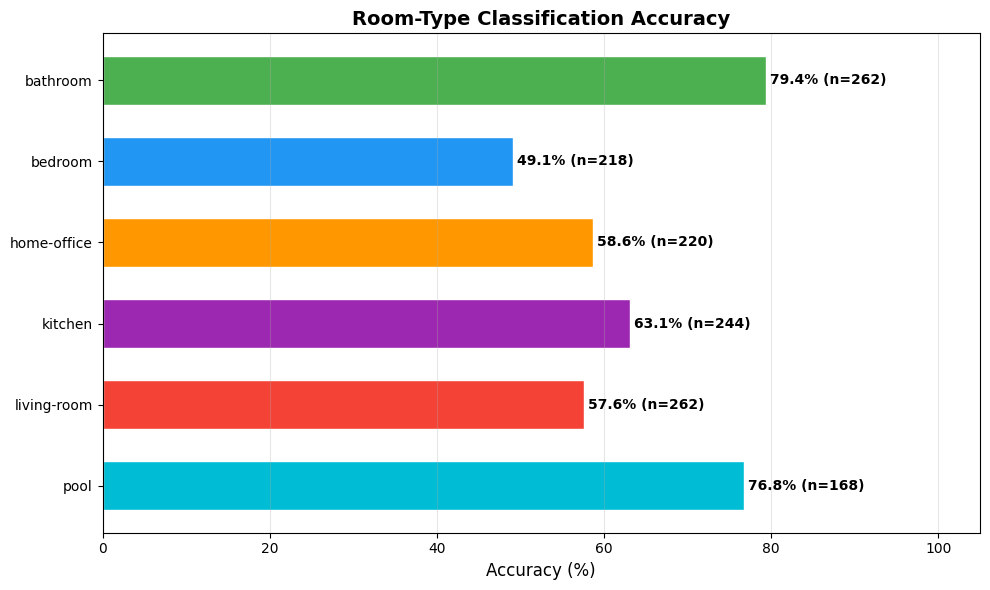

In [20]:
# %% ===============================
# 18. PER-ROOM-TYPE ACCURACY WITH BAR CHART
# ===============================
print("\n" + "="*40)
print("  ROOM-TYPE ACCURACY")
print("="*40)

# Compute per-room accuracy (using synonym matching)
room_stats = defaultdict(lambda: {'correct': 0, 'total': 0})

for idx in range(len(test_df_eval)):
    room = test_df_eval.iloc[idx]['room_type']
    gen  = ' '.join(hypotheses_greedy[idx])

    room_stats[room]['total'] += 1
    if check_room_match(room, gen):
        room_stats[room]['correct'] += 1

# Sort by room name
sorted_rooms = sorted(room_stats.keys())

# Print text bar chart
for room in sorted_rooms:
    stats = room_stats[room]
    acc = stats['correct'] / max(stats['total'], 1) * 100
    bar_len = int(acc / 5)  # scale: 5% per block
    bar = '█' * bar_len
    print(f"  {room:<15} {acc:5.1f}%  {bar}")

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))

room_names = sorted_rooms
room_accs  = [room_stats[r]['correct'] / max(room_stats[r]['total'], 1) * 100 for r in room_names]
room_counts = [room_stats[r]['total'] for r in room_names]

colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336', '#00BCD4',
          '#795548', '#607D8B', '#E91E63', '#3F51B5']
bar_colors = [colors[i % len(colors)] for i in range(len(room_names))]

bars = ax.barh(room_names, room_accs, color=bar_colors, edgecolor='white', height=0.6)

# Add labels on bars
for bar, acc, count in zip(bars, room_accs, room_counts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}% (n={count})', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Room-Type Classification Accuracy', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/kaggle/working/room_type_accuracy_v3.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
# %% ===============================
# 19. SAVE TEST PREDICTIONS CSV
# ===============================
predictions = []
for idx in range(len(test_df_eval)):
    row = test_df_eval.iloc[idx]
    predictions.append({
        'local_path':   row['local_path'],
        'room_type':    row['room_type'],
        'true_caption': row['description'],  # ← FIXED: 'description' not 'caption'
        'generated':    ' '.join(hypotheses_greedy[idx]),
    })

pred_df = pd.DataFrame(predictions)
pred_df.to_csv('/kaggle/working/test_predictions_v2.csv', index=False)
print(f"Saved {len(pred_df)} predictions to test_predictions_v2.csv ✓")

Saved 1374 predictions to test_predictions_v2.csv ✓


In [23]:
# %% ===============================
# 20. SAVE METRICS + EXPORT DECODER
# ===============================

# Build per-room accuracy dict for JSON
room_acc_dict = {}
for room in sorted_rooms:
    stats = room_stats[room]
    room_acc_dict[room] = round(stats['correct'] / max(stats['total'], 1) * 100, 1)

metrics = {
    'model': 'LSTM Decoder v2 (Attention + 2-layer)',
    'encoder': 'ResNet50 (frozen, from teammate)',
    'best_val_loss': float(best_val_loss),
    'test_samples': len(test_df_eval),
    'BLEU-1': float(bleu1_greedy),
    'BLEU-4': float(bleu4_greedy),
    'METEOR': float(avg_meteor),
    'ROUGE-L': float(avg_rougeL),
    'CIDEr': float(cider_score),
    'Room_Acc_%': float(room_acc),
    'room_type_accuracy': room_acc_dict,
    'hyperparams': {
        'embed_dim': EMBED_DIM, 'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS, 'dropout': DROPOUT,
        'lr': LR, 'batch_size': BATCH_SIZE,
        'grad_clip': GRAD_CLIP, 'label_smoothing': LABEL_SMOOTH,
    }
}
with open('/kaggle/working/eval_metrics_v2.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("\nMetrics saved to eval_metrics_v2.json ")

# Export decoder
torch.save({
    'decoder_state_dict': decoder.state_dict(),
    'model_class':        'LSTMDecoderV2',
    'embed_dim':          EMBED_DIM,
    'hidden_dim':         HIDDEN_DIM,
    'num_layers':         NUM_LAYERS,
    'vocab_size':         vocab_size,
    'pad_idx':            pad_idx,
    'start_idx':          start_idx,
    'end_idx':            end_idx,
    'word2idx':           word2idx,
    'idx2word':           idx2word,
    'img_mean':           img_mean,
    'img_std':            img_std,
    'max_seq_len':        MAX_SEQ_LEN,
    'best_val_loss':      float(best_val_loss),
    'metrics':            metrics,
}, '/kaggle/working/lstm_decoder_export.pth')
print("Decoder exported to lstm_decoder_export.pth ")
print("\nAll done!")



Metrics saved to eval_metrics_v2.json 
Decoder exported to lstm_decoder_export.pth 

All done!
